# Bias Analysis on Diabetes Health Indicators Dataset
This notebook implements a comprehensive bias analysis, focusing on **Representation Bias**, **Historical Bias**, and **Measurement Bias**. The goal is to uncover how bias might be encoded in the dataset and to discuss implications for fair predictive modeling.

## 1. Data Loading and Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/2A/S4_TU_Delft/Q3/SEN163B-Responsible_Data_Analytics/Diabetes_Prediction/project_final/data/diabetes_012_health_indicators_BRFSS2015.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [3]:
# Number of records:
print("Number of records: ",  df.shape[0])
# Number of features:
print("Number of features: ",  df.shape[1])

# Are there missing values that could create biases
# print(pd_gdata.isin(['NA']).sum(axis=0))
print("Number of missing values for each attribute: ", df.isnull().sum())

Number of records:  253680
Number of features:  22
Number of missing values for each attribute:  Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


## 2. Representation Bias Analysis
**Representation bias** occurs when certain demographic groups are underrepresented or misrepresented in the dataset, leading to unfair outcomes or poor model generalization.The distribution of diabetes outcomes is analyzed by sex and limitations in population representation are discussed.

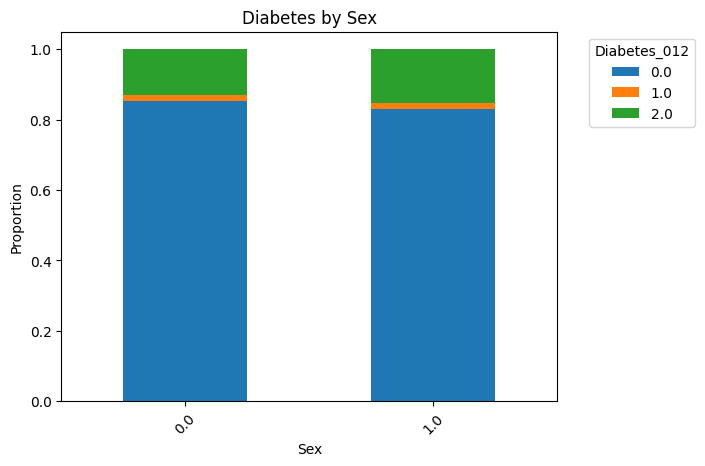

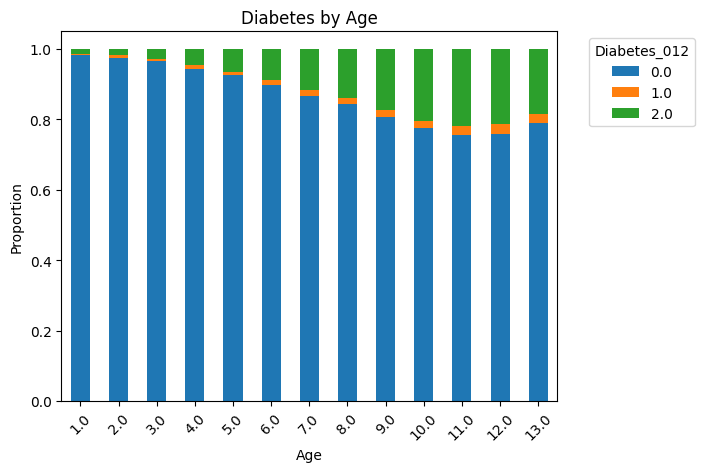

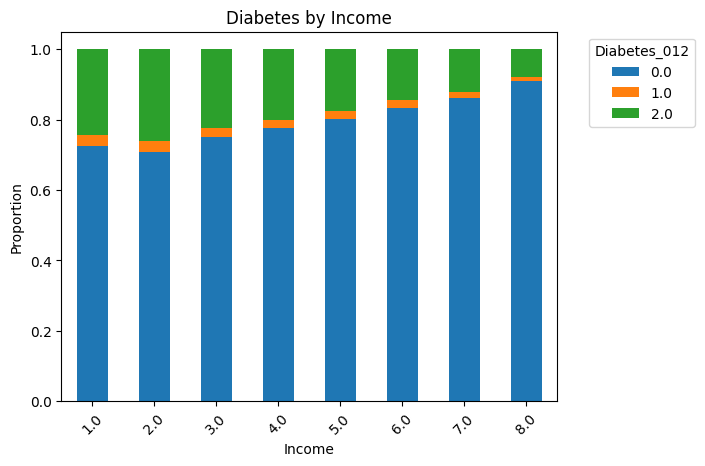

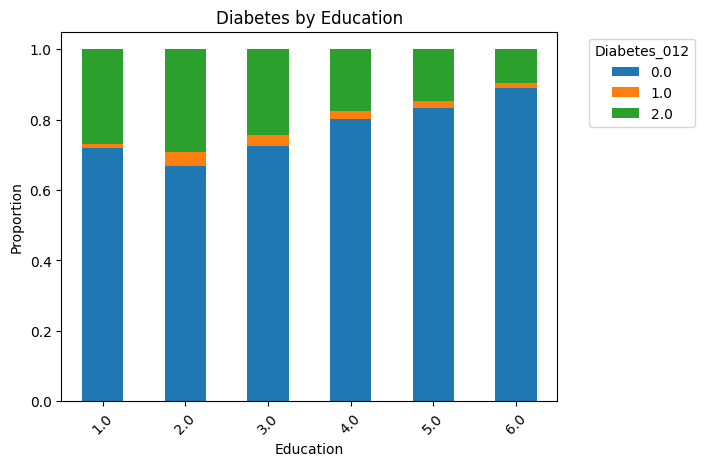

In [4]:
# Compare outcome variable 'Diabetes_012' across demographics
bias_vars = ['Sex', 'Age', 'Income', 'Education', 'Race'] if 'Race' in df.columns else ['Sex', 'Age', 'Income', 'Education']
for var in bias_vars:
    pd.crosstab(df[var], df['Diabetes_012'], normalize='index').plot(kind='bar', stacked=True)
    plt.title(f'Diabetes by {var}')
    plt.ylabel('Proportion')
    plt.legend(title='Diabetes_012', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.show()

In [5]:
# Distribution of diabetes types by sex
gender_dist = df.groupby("Sex")["Diabetes_012"].value_counts(normalize=True).unstack()
gender_dist["Total_Count"] = df.groupby("Sex").size()
gender_dist

Diabetes_012,0.0,1.0,2.0,Total_Count
Sex,,,,
0.0,0.851980,0.018341,0.129679,141974
1.0,0.830251,0.018146,0.151603,111706


From the output, we observe a higher number of male entries (Sex=0) compared to female entries (Sex=1). While the proportion of non-diabetic individuals is high in both groups, females show a slightly higher prevalence diabetes. The underrepresentation of certain groups may lead to skewed models that do not generalize well across the full population spectrum. 


In [6]:
# Distribution of diabetes types by Education
edu_dist = df.groupby("Education")["Diabetes_012"].value_counts(normalize=True).unstack()
edu_dist["Total_Count"] = df.groupby("Education").size()
edu_dist

Diabetes_012,0.0,1.0,2.0,Total_Count
Education,,,,
1.0,0.718391,0.011494,0.270115,174
2.0,0.667574,0.039822,0.292605,4043
3.0,0.724625,0.033129,0.242245,9478
4.0,0.802135,0.021514,0.176351,62750
5.0,0.832828,0.019067,0.148105,69910
6.0,0.889392,0.013706,0.096902,107325


In [7]:
# Distribution of diabetes types by Income
inc_dist = df.groupby("Income")["Diabetes_012"].value_counts(normalize=True).unstack()
inc_dist["Total_Count"] = df.groupby("Income").size()
inc_dist

Diabetes_012,0.0,1.0,2.0,Total_Count
Income,,,,
1.0,0.725104,0.032005,0.242891,9811
2.0,0.707884,0.030213,0.261903,11783
3.0,0.750594,0.026322,0.223084,15994
4.0,0.775863,0.022796,0.201341,20135
5.0,0.803307,0.022679,0.174014,25883
6.0,0.834412,0.020510,0.145078,36470
7.0,0.861172,0.017006,0.121821,43219
8.0,0.909211,0.011185,0.079604,90385


## 3. Historical Bias Analysis
**Historical bias** refers to bias inherited from structural or systemic inequalities encoded in historical data. We examine how diabetes outcomes vary across different age groups.

In [8]:
# Create age bins
age_bins = pd.cut(df["Age"],
                  bins= 13, 
                  labels=[
                        "18-24", "25-29", "30-34", "35-39",
                        "40-44", "45-49","50-54", "55-59",
                        "60-64", "65-69","70-74", "75-79","+80"  ])
df["AgeGroup"] = age_bins

# Diabetes distribution by age group
age_dist = df.groupby("AgeGroup")["Diabetes_012"].value_counts(normalize=True).unstack()
age_dist

/var/folders/3w/8fsd48l51sg5lw_r62023_n80000gn/T/ipykernel_78478/1176248813.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_dist = df.groupby("AgeGroup")["Diabetes_012"].value_counts(normalize=True).unstack()


Diabetes_012,0.0,1.0,2.0
AgeGroup,,,
18-24,0.982632,0.003684,0.013684
25-29,0.974467,0.007107,0.018426
30-34,0.965297,0.006473,0.028230
35-39,0.944440,0.010273,0.045287
40-44,0.924862,0.010089,0.065049
45-49,0.896362,0.015742,0.087895
50-54,0.866763,0.015885,0.117352
55-59,0.843896,0.017839,0.138265
60-64,0.806431,0.021117,0.172452


The results clearly show that diabetes prevalence increases with age. This is expected from a public health standpoint, but it may also reflect systemic inequalities in healthcare, such as delayed diagnosis or lack of preventive measures in older populations.

## 4. Measurement Bias Analysis
**Measurement bias** arises when data collection instruments or self-reported behaviors yield inconsistent or inaccurate results across subpopulations. We inspect health-related features by sex.

In [9]:
# Compare mean values of key health conditions by sex
measurement_bias = df.groupby("Sex")[["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack"]].mean()
measurement_bias

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
Sex,,,,
0.0,0.406081,0.410441,0.040050,0.071879
1.0,0.458131,0.441507,0.041233,0.122536


Females report higher average values for most health conditions. This could reflect true health differences, but it may also result from differences in reporting, access to diagnosis, or bias in the healthcare system. For example, men may underreport symptoms, or diagnostic criteria may vary subtly by sex.

In [10]:
# Compare mean values of key health conditions by age
measurement_bias = df.groupby("Age")[["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack"]].mean()
measurement_bias

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
Age,,,,
1.0,0.086316,0.088070,0.003684,0.005088
2.0,0.115952,0.125428,0.003817,0.007107
3.0,0.147083,0.164344,0.007462,0.011328
4.0,0.185850,0.213195,0.009911,0.013962
5.0,0.231541,0.265210,0.014173,0.021724
6.0,0.289369,0.331248,0.018568,0.035925
7.0,0.359466,0.390553,0.027438,0.054154
8.0,0.429716,0.453749,0.035191,0.073073
9.0,0.496872,0.508032,0.042534,0.101011


In [11]:
# Compare mean values of key health conditions by income
measurement_bias = df.groupby("Income")[["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack"]].mean()
measurement_bias

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
Income,,,,
1.0,0.548772,0.490980,0.091530,0.158292
2.0,0.591870,0.526776,0.099805,0.186455
3.0,0.552957,0.476304,0.080280,0.157497
4.0,0.528284,0.463621,0.065259,0.140452
5.0,0.497547,0.454005,0.054321,0.122126
6.0,0.462188,0.434878,0.039375,0.099973
7.0,0.409010,0.421389,0.028969,0.078762
8.0,0.327256,0.373856,0.016883,0.050727
